In [293]:
import pandas as pd
import numpy as np
import math

import seaborn as sns
import matplotlib.pyplot as plt

import sys
sys.path.insert(1, '../../scripts/')
from human_me.utils.load_environmental_variables import *
prebuild = '/data2/hratch/human_me/prebuild/'

# Protein turnover

In [294]:
def explode(df_, explode_cols, sep = None, fill_value=float('nan'), preserve_index=False):
    '''Split entries with multiple values separated by a separator into multiple rows (or entries in lists)
    
    https://stackoverflow.com/questions/12680754/split-explode-pandas-dataframe-string-entry-to-separate-rows
    
    df_: pd.DataFrame
    explode_cols: list
        columns to split
    sep: separator
        if None, already in list format
    fill_value: 
        if empty entry, what to fill it with
    preserve_index: bool
        keep original index values for each new row
    
    '''
    res = None
    for col in explode_cols:
        if res is None:
            df = df_.copy()
        else:
            df = res.copy()
        
        df[col]=df[col].str.split(sep)

        idx_cols = df.columns.difference([col])
        # calculate lengths of lists
        lens = df[col].apply(lambda x: len(x))

        idx = np.repeat(df.index.values, lens)
        # create "exploded" DF
        res = (pd.DataFrame({
                    col_:np.repeat(df[col_].values, lens)
                    for col_ in idx_cols},
                    index=idx)
                 .assign(**{col_:np.concatenate(df.loc[lens>0, col_].values)
                                for col_ in [col]}))
        # append those rows that have empty lists
        if (lens == 0).any():
            # at least one list in cells is empty
            res = (res.append(df.loc[lens==0, idx_cols], sort=False)
                      .fillna(fill_value))
        # revert the original index order
        res = res.sort_index()
        # reset index if requested
        if not preserve_index:        
            res.reset_index(drop=True, inplace = True)
    return res

def expand_id(df_):
    # expand uniprot id
    df = df_.copy()
    df = df[df.Uniprot.notna()]
    df['Uniprot'] = df['Uniprot'].astype(str)
    df=explode(df[df['Uniprot'].notna()], explode_cols = ['Uniprot'], sep = ';')
    df=explode(df, explode_cols = ['Uniprot'], sep = '/')
    return df

def merge_redundant(df_):
    df = df_.groupby(by=df_.Uniprot, axis=0).median()
    if 'nan' in df.index.tolist():
        df.drop(index = ['nan'], inplace = True)
    return df

In [295]:
hela = pd.read_excel(prebuild + 'Cambridge_protein_turnover.xls', sheet_name = 0)
c2c12 = pd.read_excel(prebuild + 'Cambridge_protein_turnover.xls', sheet_name = 1)
mval = np.median(hela.kdeg.tolist() + c2c12.kdeg.tolist())
print('The median degradation rate before mapping IDs: {:.4f} (hrs)'.format(mval))

dfs = [hela, c2c12]

# only keep these columns
cols = ['half-life t1/2 in h', 'kdeg', 'Uniprot']
dfs = [df[cols] for df in dfs]

# expand uniprot id
dfs = [expand_id(df) for df in dfs]

# merge duplicate ids by median value
dfs = [merge_redundant(df) for df in dfs]

# combine
hela, c2c12 = dfs[0], dfs[1]
hela['cell_line'] = 'HeLA'
c2c12['cell_line'] = 'C2C12'
ap = pd.concat([hela, c2c12], axis = 0, ignore_index = False)
ap['UNIPROT_ID'] = ap.index
ap.reset_index(inplace = True, drop = True)

The median degradation rate before mapping IDs: 0.0183 (hrs)


#### Map to HGNC IDs

In [296]:
# conserve existing mapping (consider many to one)
psim_me = pd.read_hdf('/data2/hratch/human_me/temp_psim.h5', key = 'n_exons') # ok to use final psim also
temp = psim_me[psim_me.UNIPROT_ID.isin(ap.UNIPROT_ID)][['UNIPROT_ID', 'HGNC_ID']]

mapper = dict()
for i in temp.index:
    hgnc_id = temp.loc[i, 'HGNC_ID']
    uniprot_id = temp.loc[i, 'UNIPROT_ID']
    
    if uniprot_id in mapper:
        mapper[uniprot_id] += [hgnc_id]
    else:
        mapper[uniprot_id] = [hgnc_id]

mapper = {k: ';'.join(sorted(set(v))) for k,v in mapper.items()}
ap['HGNC_ID'] = ap.UNIPROT_ID.map(mapper)

ap['HGNC_ID'] = ap.HGNC_ID.astype(str)
ap = explode(ap, explode_cols = ['HGNC_ID'], sep = ';', fill_value=float('nan'), preserve_index=False)
ap.replace('nan', float('nan'), inplace = True)

In [297]:
p1 = ap[ap.HGNC_ID.notna()]
p2 = ap[ap.HGNC_ID.isna()]

mapper = pd.read_csv(prebuild + 'Cambridge_uniprot_to_hgnc.txt', sep = '\t')
p2['HGNC_ID'] = p2.UNIPROT_ID.map(dict(zip(mapper.From, mapper.To)))
ap = pd.concat([p1, p2], axis = 0, ignore_index = True)
# ap.to_csv(build_files_path + 'protein_turnover.csv')

/home/hratch/Projects/human_me/me_env/lib/python3.6/site-packages/ipykernel_launcher.py:5 SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


# Short-Lived Proteins

In [298]:
# get short-lived proteins (https://doi.org/10.1016/j.molcel.2021.09.015)
sheet_names = ['U2OS', 'HEK293T', 'HCT116', 'RPE1']
slp = dict()
slp_ids = list()
for sn in sheet_names:
    df = pd.read_excel(prebuild + 'Li_2021_TableS2_short_lived_protein_turnover.xlsx', 
                 sheet_name = sn)[['Uniprot ID', 'Gene symbol', 'Half-life', 'Short-lived']]
    
    slp_ids += df[df['Short-lived'] == 'short-lived']['Uniprot ID'].tolist()
    
    df['kdeg'] = df['Half-life'].apply(lambda x: math.log(2)/x)
    df['cell_line'] = sn
    df.rename(columns = {'Half-life': 'half-life t1/2 in h', 
                         'Uniprot ID': 'UNIPROT_ID'}, inplace = True)
    df = df[['UNIPROT_ID', 'cell_line', 'half-life t1/2 in h', 'kdeg', 'Gene symbol']]
    
    slp[sn] = df
slp_ids = sorted(set(slp_ids))

# only keep proteins that were categorized as short-lived in 
# at-least one cell line
slp_hl = pd.DataFrame(index = slp_ids)
for cell_line, df in slp.items():
    df.index = df.UNIPROT_ID
    present = df.loc[df.index.isin(slp_ids),:]
    
    df_2 = pd.DataFrame(index = slp_ids, columns = df.columns)
    df_2.loc[present.index, present.columns] = present.values
    
    df_2['UNIPROT_ID'] = df_2.index
    df_2.reset_index(drop = True, inplace = True)
    
    slp_hl[cell_line] = df_2['half-life t1/2 in h'].tolist()
    
    slp[cell_line] = df_2

slp_hl['Median'] = slp_hl.median(axis = 1).tolist()

In [299]:
print('The # of genes that are short-lived in atleast one cell line from the Li dataset: {}'.format(len(slp_ids)))

print('The total proteins measured in the \
Cambridge dataset is: {}'.format(len(ap.UNIPROT_ID.unique())))

overlap_ids = list(set(ap.UNIPROT_ID).intersection(slp_ids))
print('The overlap in proteins between the two datasets is: {}'.format(len(overlap_ids)))


The # of genes that are short-lived in atleast one cell line from the Li dataset: 1017
The total proteins measured in the Cambridge dataset is: 31807
The overlap in proteins between the two datasets is: 108


/home/hratch/Projects/human_me/me_env/lib/python3.6/site-packages/seaborn/distributions.py:2619 FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
/home/hratch/Projects/human_me/me_env/lib/python3.6/site-packages/seaborn/distributions.py:2619 FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
/home/hratch/Projects/human_me/me_env/lib/python3.6/site-packages/seaborn/distributions.py:2619 FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level fun

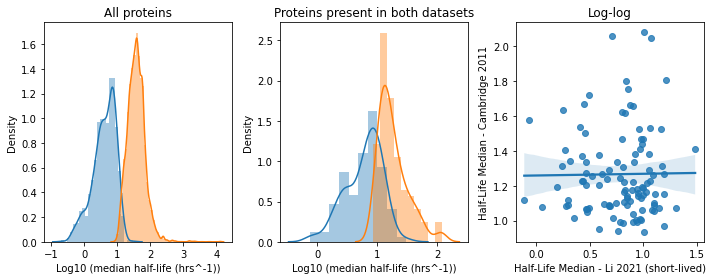

In [300]:
fig, ax = plt.subplots(figsize = (10,4), ncols = 3)

g1a = sns.distplot(np.log10(slp_hl.Median), ax = ax[0])
g1b = sns.distplot(np.log10(ap.groupby(ap.UNIPROT_ID).median()['half-life t1/2 in h']), ax = ax[0])
ax[0].set_title('All proteins')

vdf1 = slp_hl.loc[overlap_ids]
vdf2 = ap[ap.UNIPROT_ID.isin(overlap_ids)]
g2a = sns.distplot(np.log10(vdf1.Median), ax = ax[1])
g2b = sns.distplot(np.log10(vdf2.groupby(vdf2.UNIPROT_ID).median()['half-life t1/2 in h']), ax = ax[1])
ax[1].set_title('Proteins present in both datasets')


for i in range(2):
    ax[i].set_xlabel('Log10 (median half-life (hrs^-1))')

    
vdf1['Median2'] = vdf2.groupby(vdf2.UNIPROT_ID).median().loc[vdf1.index]['half-life t1/2 in h'].tolist()    
g3 = sns.regplot(np.log10(vdf1['Median']), y = np.log10(vdf1['Median2']), ax = ax[2])
ax[2].set_xlabel('Half-Life Median - Li 2021 (short-lived)')
ax[2].set_ylabel('Half-Life Median - Cambridge 2011')
ax[2].set_title('Log-log')

fig.tight_layout()

In [301]:
# map the hgncs
mapper = ap[ap.UNIPROT_ID.isin(overlap_ids)]
mapper = dict(zip(mapper.UNIPROT_ID, mapper.HGNC_ID))

slp_ids = list(set(slp_ids).difference(mapper.keys()))
psim_me = pd.read_hdf('/data2/hratch/human_me/temp_psim.h5', key = 'n_exons') # ok to use final psim also
m2 = psim_me[psim_me.UNIPROT_ID.isin(slp_ids)]
m2 = dict(zip(m2.UNIPROT_ID, m2.HGNC_ID))
for k,v in m2.items():
    mapper[k] = v
mapper = {k: v for k,v in mapper.items() if v != float('nan')}

print('Of the {} short-lived proteins, {} mapped to an \
HGNC ID'.format(slp_hl.shape[0], len(mapper)))

Of the 1017 short-lived proteins, 848 mapped to an HGNC ID


In [302]:
# append to cambridge dataset
ap['Study'] = 'Cambridge 2011'
for df in slp.values():
    df.drop(columns = ['Gene symbol'], inplace = True)
    df['HGNC_ID'] = df.UNIPROT_ID.map(mapper)
    df = df[df.cell_line.notna()]
    df.reset_index(inplace = True, drop = True)
    df['Study'] = 'Li 2021'
    ap = pd.concat([ap, df])
ap.reset_index(inplace = True, drop = True)
ap['kdeg'] = ap.kdeg.astype('float')

/home/hratch/Projects/human_me/me_env/lib/python3.6/site-packages/ipykernel_launcher.py:8 SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [343]:
print('The median degradation constant prior to incorporating \
short lived proteins: {}'.format(ap[(ap.Study == 'Cambridge 2011')].kdeg.median()))

print('The median degradation constant after incorporating \
short lived proteins: {}'.format(ap.kdeg.median()))

The median degradation constant prior to incorporating short lived proteins: 0.018766277718350884
The median degradation constant after incorporating short lived proteins: 0.019808138247250934


In [344]:
ap.to_csv(build_files_path + 'protein_turnover.csv')


